# Data Acquisition and Loading

**Data Source:**  
https://www.airqualityni.co.uk/data

**License:**  
Open Government Licence (UK) – for educational and research use.

The dataset includes pollutants such as NO₂, O₃, PM₂.₅, and PM₁₀, along with weather data (temperature, wind speed, wind direction).  
The data is stored as a CSV file in the `data/` directory and is loaded using `pandas`.

We then inspect:
- Dataset shape (rows × columns)
- Data types
- Missing values
- A sample of the first few rows

In [2]:
import pandas as pd

In [5]:
df = pd.read_csv("/Users/Owner/cmse492_project/data/raw/Dataset.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("Data Types:\n", df.dtypes)
print("\nMissing Values Summary:\n", df.isna().sum())

Shape: 179040 rows × 24 columns

Data Types:
 Date                                                                  object
Time                                                                  object
Belfast Centre/ Ozone                                                 object
Belfast Centre/ Ozone/ Status                                         object
Belfast Centre/ Nitric oxide                                          object
Belfast Centre/ Nitric oxide/ Status                                  object
Belfast Centre/ Nitrogen dioxide                                      object
Belfast Centre/ Nitrogen dioxide/ Status                              object
Belfast Centre/ Nitrogen oxides as nitrogen dioxide                   object
Belfast Centre/ Nitrogen oxides as nitrogen dioxide/ Status           object
Belfast Centre/ Sulphur dioxide                                       object
Belfast Centre/ Sulphur dioxide/ Status                               object
Belfast Centre/ Carbon monoxid

In [6]:
df.describe()

,Date,Time,Belfast Centre/ Ozone,Belfast Centre/ Ozone/ Status,Belfast Centre/ Nitric oxide,Belfast Centre/ Nitric oxide/ Status,Belfast Centre/ Nitrogen dioxide,Belfast Centre/ Nitrogen dioxide/ Status,Belfast Centre/ Nitrogen oxides as nitrogen dioxide,Belfast Centre/ Nitrogen oxides as nitrogen dioxide/ Status,...,Belfast Centre/ PM10 particulate matter (Hourly measured),Belfast Centre/ PM10 particulate matter (Hourly measured)/ Status,Belfast Centre/ PM2.5 particulate matter (Hourly measured),Belfast Centre/ PM2.5 particulate matter (Hourly measured)/ Status,Belfast Centre/ Modelled Wind Direction,Belfast Centre/ Modelled Wind Direction/ Status,Belfast Centre/ Modelled Wind Speed,Belfast Centre/ Modelled Wind Speed/ Status,Belfast Centre/ Modelled Temperature,Belfast Centre/ Modelled Temperature/ Status
count,179040,179040,179040,179040,179040,179040,179040,179040,179040,179040,...,179040,179040,179040,179040,179040,179040,179040,179040,179040,179040
unique,1492,96,9121,3,23443,3,27330,3,26412,3,...,2000,3,1506,3,3590,2,195,2,290,2
top,31/01/2025,01:00,No data,No data,No data,No data,No data,No data,No data,No data,...,No data,No data,No data,No data,No data,No data,No data,No data,No data,No data
freq,120,2984,144371,143232,151558,143232,151559,143232,151559,143232,...,143624,143232,143624,143232,143856,143856,143856,143856,143856,143856


In [7]:
print("here is the sample data: ")
df.head()

here is the sample data: 


,Date,Time,Belfast Centre/ Ozone,Belfast Centre/ Ozone/ Status,Belfast Centre/ Nitric oxide,Belfast Centre/ Nitric oxide/ Status,Belfast Centre/ Nitrogen dioxide,Belfast Centre/ Nitrogen dioxide/ Status,Belfast Centre/ Nitrogen oxides as nitrogen dioxide,Belfast Centre/ Nitrogen oxides as nitrogen dioxide/ Status,...,Belfast Centre/ PM10 particulate matter (Hourly measured),Belfast Centre/ PM10 particulate matter (Hourly measured)/ Status,Belfast Centre/ PM2.5 particulate matter (Hourly measured),Belfast Centre/ PM2.5 particulate matter (Hourly measured)/ Status,Belfast Centre/ Modelled Wind Direction,Belfast Centre/ Modelled Wind Direction/ Status,Belfast Centre/ Modelled Wind Speed,Belfast Centre/ Modelled Wind Speed/ Status,Belfast Centre/ Modelled Temperature,Belfast Centre/ Modelled Temperature/ Status
0,01/01/2021,01:00,48.90907,V µg/m³,0.25111,V µg/m³,5.00001,V µg/m³,5.38503,V µg/m³,...,8.350,V µg/m³ (FIDAS),4.788,V µg/m³ (Ref.eq),5.8,P °,4.3,P m/s,1.8,P °C
1,01/01/2021,02:00,51.66347,V µg/m³,0.20926,V µg/m³,4.48721,V µg/m³,4.80807,V µg/m³,...,5.125,V µg/m³ (FIDAS),2.642,V µg/m³ (Ref.eq),8.0,P °,4.3,P m/s,1.8,P °C
2,01/01/2021,03:00,54.43647,V µg/m³,0.21972,V µg/m³,4.03844,V µg/m³,4.37534,V µg/m³,...,5.075,V µg/m³ (FIDAS),2.359,V µg/m³ (Ref.eq),18.2,P °,4.8,P m/s,2.1,P °C
3,01/01/2021,04:00,53.59898,V µg/m³,0.21972,V µg/m³,3.26915,V µg/m³,3.60605,V µg/m³,...,4.075,V µg/m³ (FIDAS),1.910,V µg/m³ (Ref.eq),21.5,P °,5.0,P m/s,2.2,P °C
4,01/01/2021,05:00,52.37067,V µg/m³,0.15694,V µg/m³,3.94238,V µg/m³,4.18302,V µg/m³,...,4.150,V µg/m³ (FIDAS),1.816,V µg/m³ (Ref.eq),22.5,P °,5.0,P m/s,2.3,P °C


### Missing data
Looking at df.describe(), we see that there are missing values denoted at "No data". here I am examining the missing data:

In [8]:
total = len(df["Belfast Centre/ Nitrogen dioxide"])
missing = (df["Belfast Centre/ Nitrogen dioxide"] == "No data").sum()

result = total - missing
print(f"total amount of missing data in our target variable: {missing}")
print(f"Subtracting the total number of data points from the number of missing values: {result}")

total amount of missing data in our target variable: 151559
Subtracting the total number of data points from the number of missing values: 27481


In [9]:
### code for the rest of the columns:

# I am dropping the unit of measurement here since it is practically redundant to keep:
df = df.drop(columns=[col for col in df.columns if '/ Status' in col])

for col in df.columns:
    total = len(df[col])
    missing = (df[col] == "No data").sum()
    result = total - missing

    print(f"Column: {col}")
    print(f"  Missing ('No data'): {missing}")
    print(f"  Valid entries: {result}")
    print()

Column: Date
  Missing ('No data'): 0
  Valid entries: 179040

Column: Time
  Missing ('No data'): 0
  Valid entries: 179040

Column: Belfast Centre/ Ozone
  Missing ('No data'): 144371
  Valid entries: 34669

Column: Belfast Centre/ Nitric oxide
  Missing ('No data'): 151558
  Valid entries: 27482

Column: Belfast Centre/ Nitrogen dioxide
  Missing ('No data'): 151559
  Valid entries: 27481

Column: Belfast Centre/ Nitrogen oxides as nitrogen dioxide
  Missing ('No data'): 151559
  Valid entries: 27481

Column: Belfast Centre/ Sulphur dioxide
  Missing ('No data'): 8575
  Valid entries: 170465

Column: Belfast Centre/ Carbon monoxide
  Missing ('No data'): 147570
  Valid entries: 31470

Column: Belfast Centre/ PM10 particulate matter (Hourly measured)
  Missing ('No data'): 143624
  Valid entries: 35416

Column: Belfast Centre/ PM2.5 particulate matter (Hourly measured)
  Missing ('No data'): 143624
  Valid entries: 35416

Column: Belfast Centre/ Modelled Wind Direction
  Missing ('No

#### Note
Looking at this, there's more missing data compared to the actual data, so imputation may be risky, but it may be worth analyzing. But given that we have a lot of entries of data with no missing values, we can still have a good run with dropping all columns containing "No value".

In [10]:
### updated dataframe after dropping columns with the unit of measurement
df.head()

,Date,Time,Belfast Centre/ Ozone,Belfast Centre/ Nitric oxide,Belfast Centre/ Nitrogen dioxide,Belfast Centre/ Nitrogen oxides as nitrogen dioxide,Belfast Centre/ Sulphur dioxide,Belfast Centre/ Carbon monoxide,Belfast Centre/ PM10 particulate matter (Hourly measured),Belfast Centre/ PM2.5 particulate matter (Hourly measured),Belfast Centre/ Modelled Wind Direction,Belfast Centre/ Modelled Wind Speed,Belfast Centre/ Modelled Temperature
0,01/01/2021,01:00,48.90907,0.25111,5.00001,5.38503,1.65808,0.089291,8.350,4.788,5.8,4.3,1.8
1,01/01/2021,02:00,51.66347,0.20926,4.48721,4.80807,1.18435,0.070492,5.125,2.642,8.0,4.3,1.8
2,01/01/2021,03:00,54.43647,0.21972,4.03844,4.37534,1.24356,0.077542,5.075,2.359,18.2,4.8,2.1
3,01/01/2021,04:00,53.59898,0.21972,3.26915,3.60605,0.35531,0.059919,4.075,1.910,21.5,5.0,2.2
4,01/01/2021,05:00,52.37067,0.15694,3.94238,4.18302,0.47374,0.052870,4.150,1.816,22.5,5.0,2.3


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# using os to address it to the figures directory
fig_dir = "/home/blansha2/cmse492_project/figures"   
os.makedirs(fig_dir, exist_ok=True)

#code to make the date time column in order to prep it for time series analysis
if 'Date' in df.columns and 'Time' in df.columns:
    try:
        df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str),
                                        dayfirst=True, errors='coerce')
    except Exception:
        df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str),
                                        errors='coerce')
else:
    datetime_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
    if datetime_cols:
        df['datetime'] = pd.to_datetime(df[datetime_cols[0]], errors='coerce')
    else:
        df['datetime'] = pd.NaT

# chat gpt suggests changing the column names for more efficient analysis, so here is the code for that:
df.columns = [c.replace(' / ', '/').replace('/ ', '/').replace(' /', '/') for c in df.columns]

col_map = {
    'Belfast Centre/Nitrogen dioxide': 'NO2',
    'Belfast Centre/Ozone': 'O3',
    'Belfast Centre/PM2.5 particulate matter (Hourly measured)': 'PM2_5',
    'Belfast Centre/PM10 particulate matter (Hourly measured)': 'PM10',
    'Belfast Centre/Carbon monoxide': 'CO',
    'Belfast Centre/Sulphur dioxide': 'SO2',
    'Belfast Centre/Nitric oxide': 'NO',
    'Belfast Centre/Nitrogen oxides as nitrogen dioxide': 'NOx',
    'Belfast Centre/Modelled Temperature': 'Temp',
    'Belfast Centre/Modelled Wind Speed': 'WindSpeed',
    'Belfast Centre/Modelled Wind Direction': 'WindDir'
}

col_map_present = {k:v for k,v in col_map.items() if k in df.columns}

df = df.rename(columns=col_map_present)
df.head()


,Date,Time,O3,NO,NO2,NOx,SO2,CO,PM10,PM2_5,WindDir,WindSpeed,Temp,datetime
0,01/01/2021,01:00,48.90907,0.25111,5.00001,5.38503,1.65808,0.089291,8.350,4.788,5.8,4.3,1.8,2021-01-01 01:00:00
1,01/01/2021,02:00,51.66347,0.20926,4.48721,4.80807,1.18435,0.070492,5.125,2.642,8.0,4.3,1.8,2021-01-01 02:00:00
2,01/01/2021,03:00,54.43647,0.21972,4.03844,4.37534,1.24356,0.077542,5.075,2.359,18.2,4.8,2.1,2021-01-01 03:00:00
3,01/01/2021,04:00,53.59898,0.21972,3.26915,3.60605,0.35531,0.059919,4.075,1.910,21.5,5.0,2.2,2021-01-01 04:00:00
4,01/01/2021,05:00,52.37067,0.15694,3.94238,4.18302,0.47374,0.052870,4.150,1.816,22.5,5.0,2.3,2021-01-01 05:00:00


In [13]:
print(df['datetime'].iloc[0] , df['datetime'].iloc[-1])

2021-01-01 01:00:00 NaT


In [13]:
# replacing missing values with nan so that I can visualize the data correctly
df = df.replace("No data", np.nan)

sum_missing = df.isna().sum()
print(f"Sum of missing data: {sum_missing}")

Sum of missing data: Date              0
Time              0
O3           144371
NO           151558
NO2          151559
NOx          151559
SO2            8575
CO           147570
PM10         143624
PM2_5        143624
WindDir      143856
WindSpeed    143856
Temp         143856
datetime       2984
dtype: int64


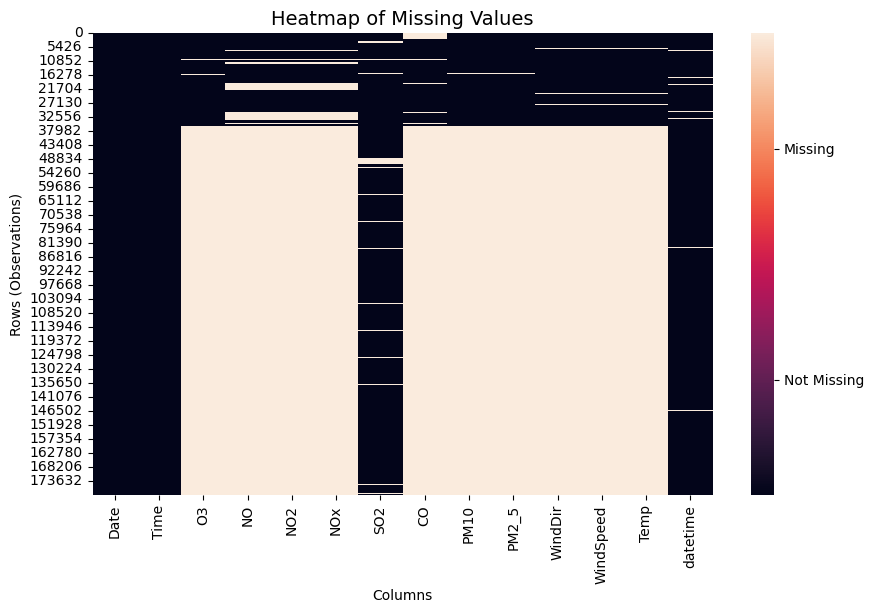

Saved to: /home/blansha2/cmse492_project/figures/Heatmap_of_missing_values.png


In [14]:
plt.figure(figsize=(10, 6))
ax = sns.heatmap(df.isna(), cbar=True)

colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0.25, 0.75])
colorbar.set_ticklabels(['Not Missing', 'Missing'])

plt.title("Heatmap of Missing Values", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows (Observations)")

outpath = os.path.join(fig_dir, "Heatmap_of_missing_values.png")
plt.savefig(outpath, dpi=150, bbox_inches='tight') 
plt.show()                                           

print("Saved to:", outpath)

#### Notes:
here we have a heatmap of the missing values, which there are a lot of missing values in this data set, more missing than non-missing in some columns which poses a problem especially when it comes to imputation techniques. When we subtracted the missing values from the number of entries, there are enough valid data entries for machine learning, roughly around 35,000 valid data entries if we dropped the missing values. however, we are working with time-series data, and it would be beneficial to have valid entries for all of the dates and times. For the time being, we will explore imputation techniques in the preprocessing portion of the project, for now lets explore the data by visualizing it.

In [15]:
### dropping the original date and time columns
df = df.drop(columns=["Date", "Time"])
df.head()

,O3,NO,NO2,NOx,SO2,CO,PM10,PM2_5,WindDir,WindSpeed,Temp,datetime
0,48.90907,0.25111,5.00001,5.38503,1.65808,0.089291,8.350,4.788,5.8,4.3,1.8,2021-01-01 01:00:00
1,51.66347,0.20926,4.48721,4.80807,1.18435,0.070492,5.125,2.642,8.0,4.3,1.8,2021-01-01 02:00:00
2,54.43647,0.21972,4.03844,4.37534,1.24356,0.077542,5.075,2.359,18.2,4.8,2.1,2021-01-01 03:00:00
3,53.59898,0.21972,3.26915,3.60605,0.35531,0.059919,4.075,1.910,21.5,5.0,2.2,2021-01-01 04:00:00
4,52.37067,0.15694,3.94238,4.18302,0.47374,0.052870,4.150,1.816,22.5,5.0,2.3,2021-01-01 05:00:00


In [18]:
processed_dir = "/home/blansha2/cmse492_project/data/processed"
os.makedirs(processed_dir, exist_ok=True)
outpath = os.path.join(processed_dir, "cleaned_data.csv")
df.to_csv(outpath, index=False)

print("Saved to:", outpath)

Saved to: /home/blansha2/cmse492_project/data/processed/cleaned_data.csv


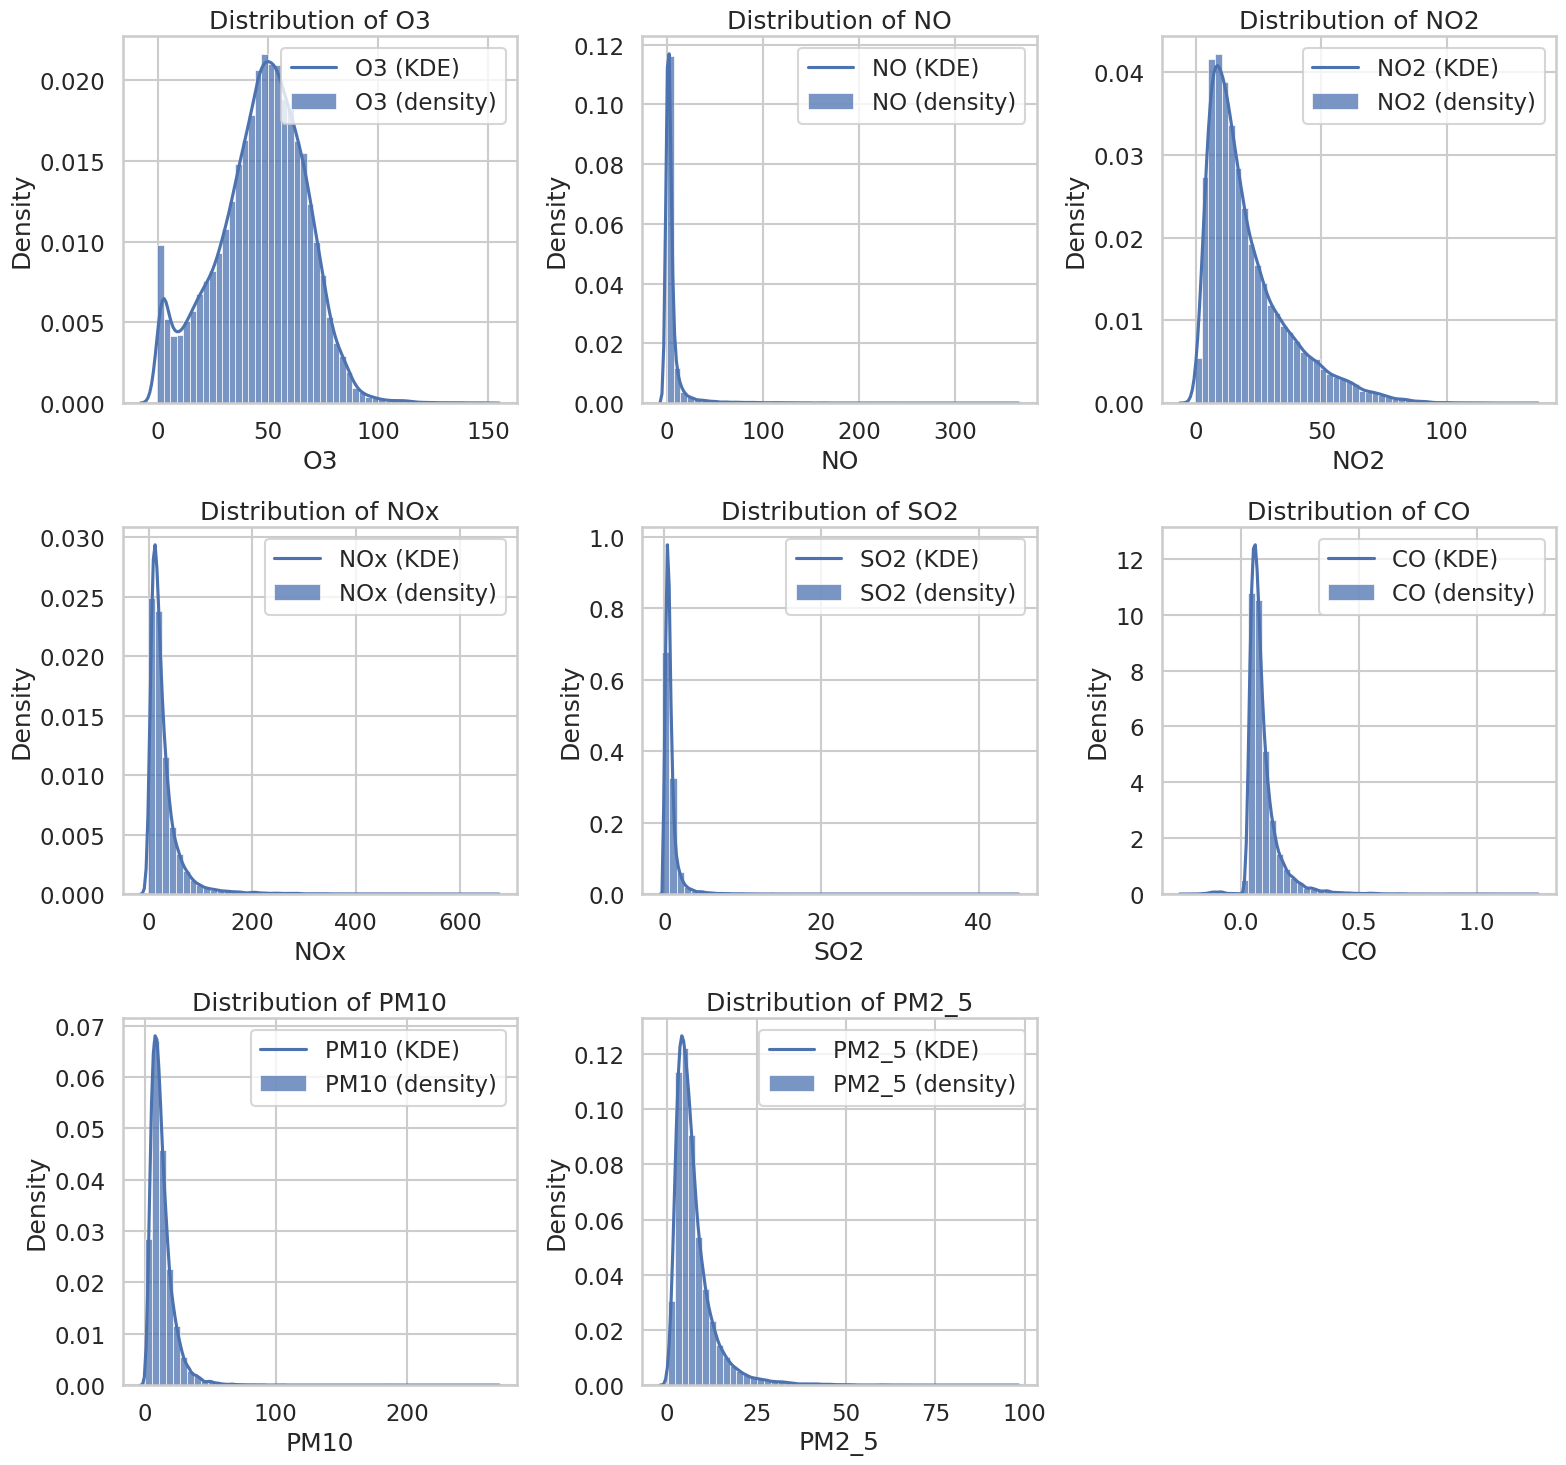

In [19]:
#distribution plots of each pollutant
import math

sns.set(style="whitegrid", context="talk")
all_pollutants = ["O3", "NO", "NO2", "NOx", "SO2", "CO", "PM10", "PM2_5"]

plot_features = [p for p in all_pollutants if p in df.columns]

num_plots = len(plot_features)
num_cols = 3
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 5 * num_rows))
axes = axes.flatten()

for ax, feat in zip(axes, plot_features):
    data = pd.to_numeric(df[feat], errors='coerce').dropna()

    if len(data) == 0:
        ax.text(0.5, 0.5, f'No numeric data for {feat}', ha='center', va='center')
        ax.set_title(f"Distribution of {feat}")
        continue

    sns.histplot(data, kde=False, stat='density', ax=ax, bins=50,
                 label=f"{feat} (density)")
    sns.kdeplot(data, ax=ax, label=f"{feat} (KDE)", bw_adjust=1)

    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.legend()

for i in range(len(plot_features), len(axes)):
    axes[i].set_visible(False)

outpath = os.path.join(fig_dir, "dist_all_pollutants_density.png")
os.makedirs(fig_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()

Rows available after coercion & dropna: 25527


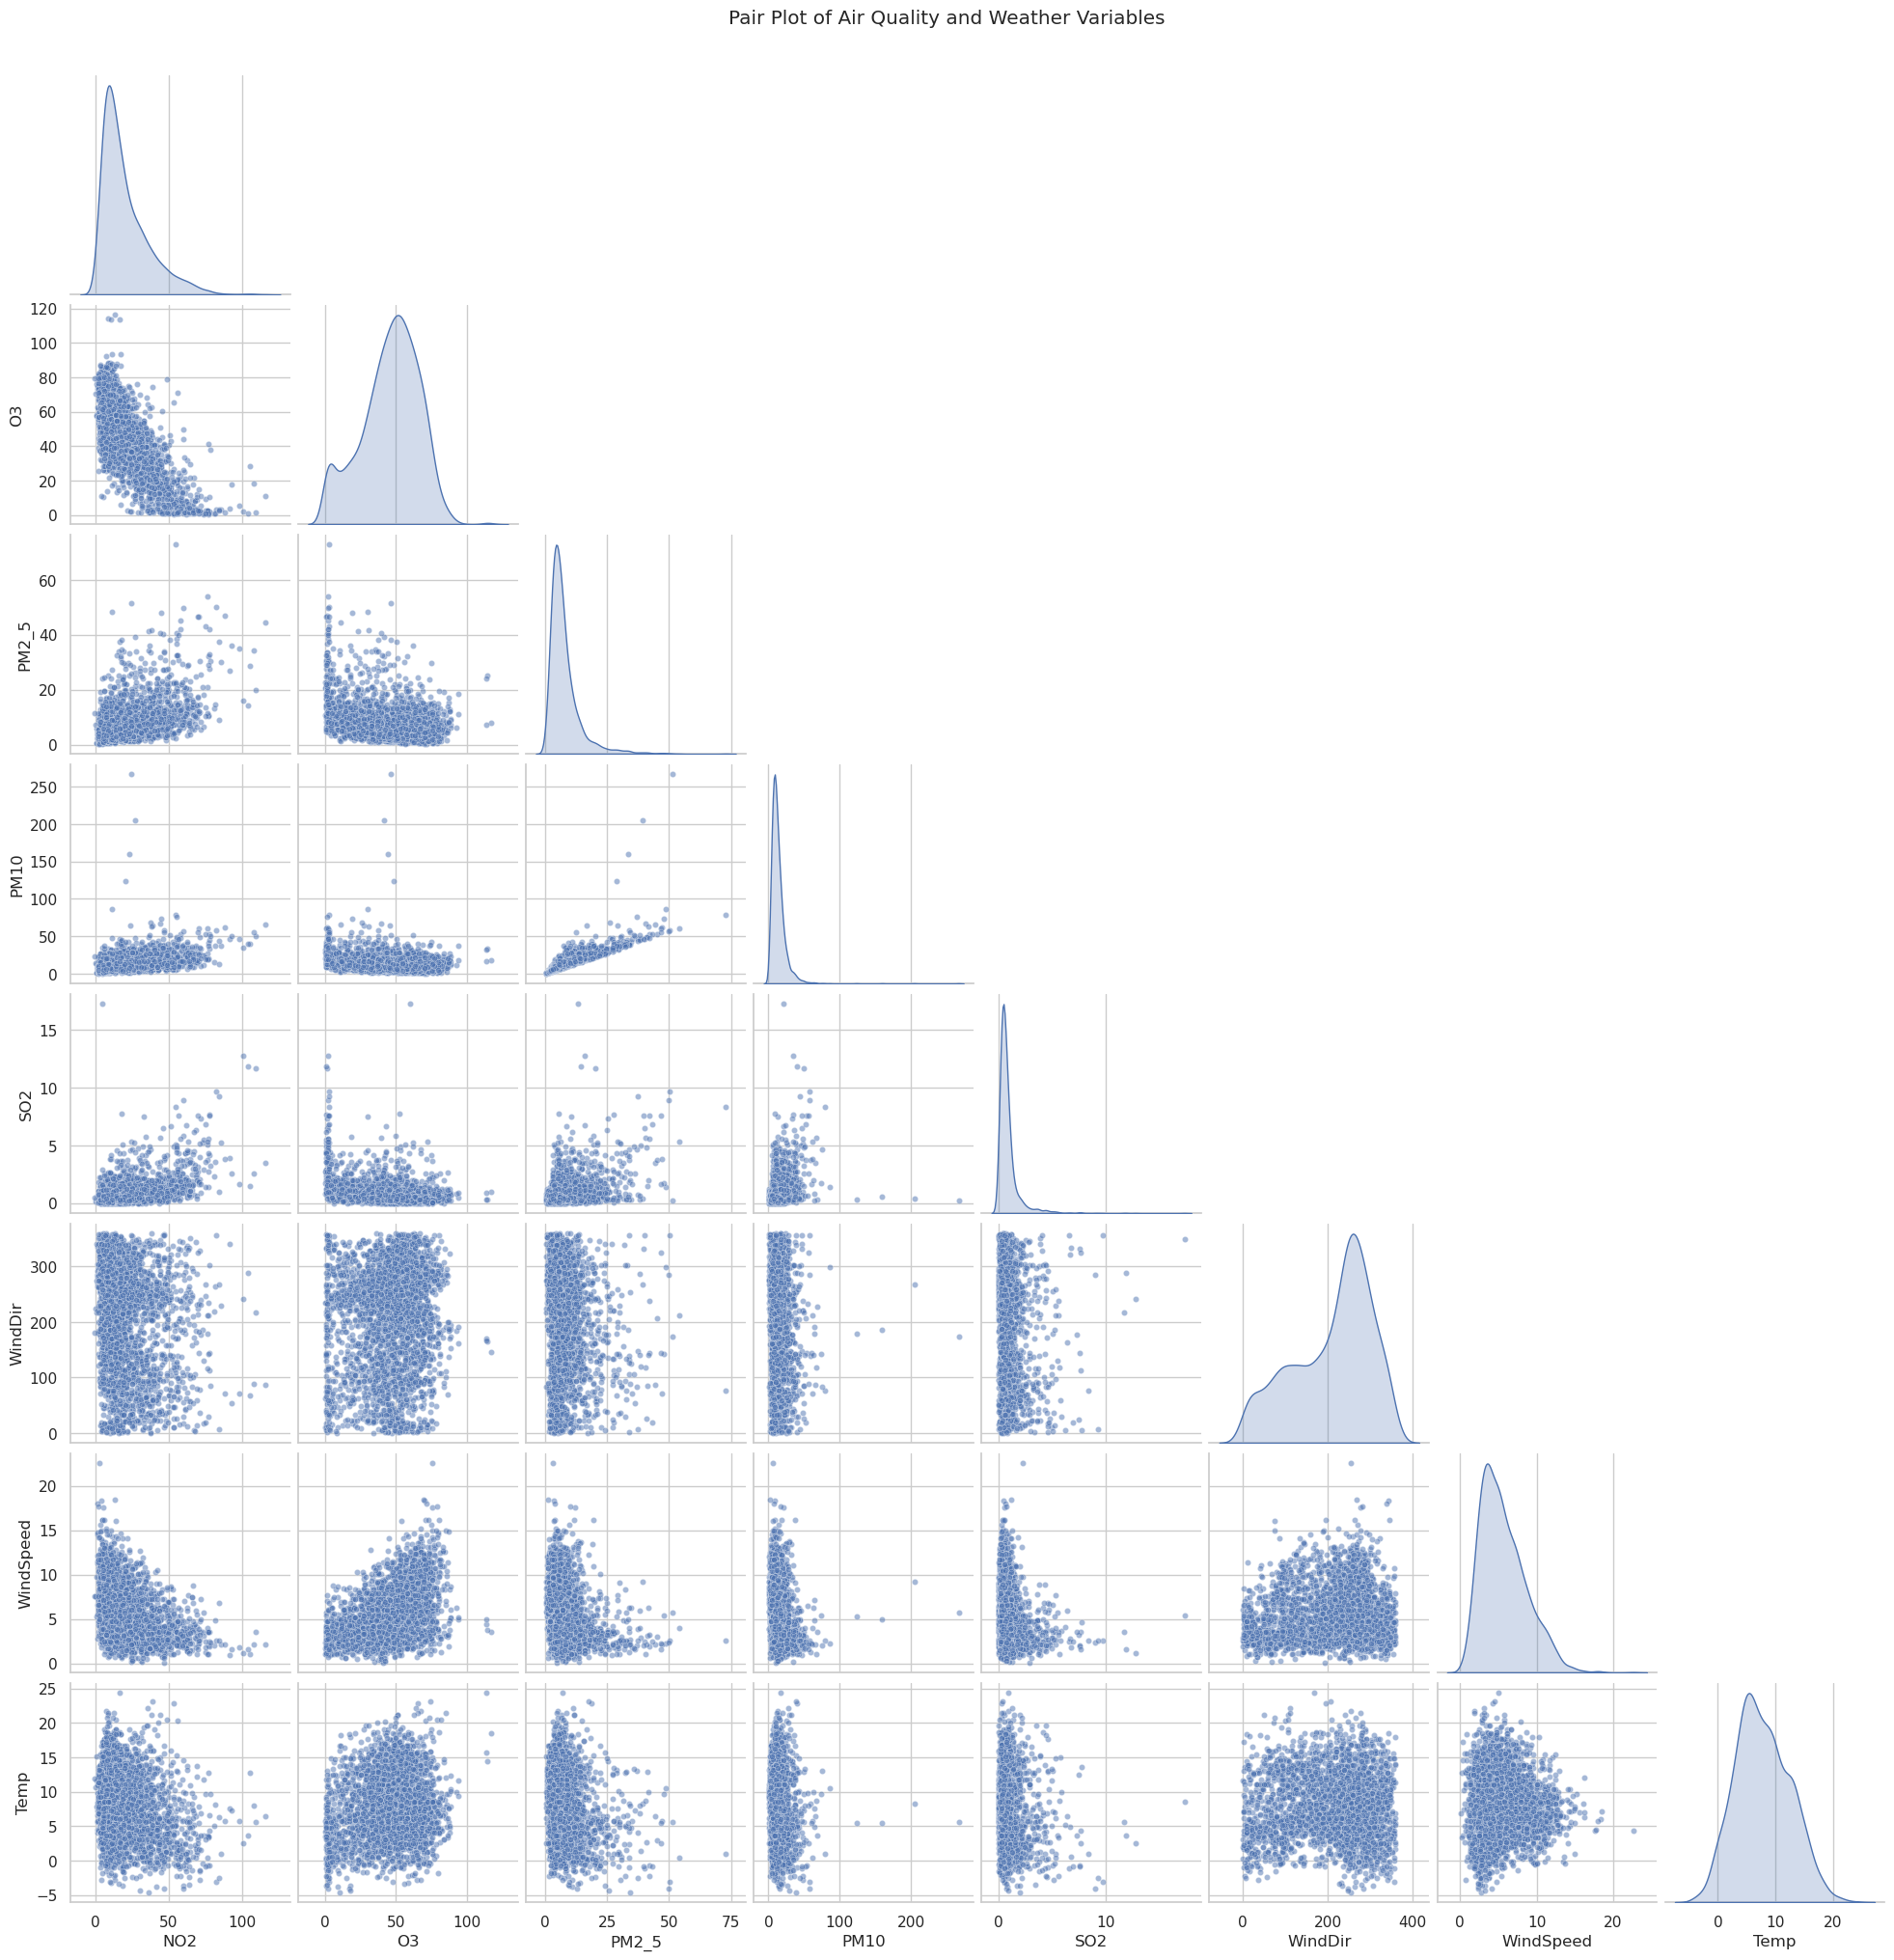

Saved: /home/blansha2/cmse492_project/figures/pairplot_air_quality_weather.png


In [20]:
pair_cols = [c for c in ['NO2', 'O3', 'PM2_5', 'PM10', 'SO2', 'WindDir', 'WindSpeed', 'Temp'] if c in df.columns]

pair_df = df[pair_cols].copy()

for col in pair_df.columns:
    if not pd.api.types.is_numeric_dtype(pair_df[col]):
        extracted = pair_df[col].astype(str).str.extract(r'(-?\d+\.\d+|-?\d+)')[0]
        pair_df[col] = pd.to_numeric(extracted, errors='coerce')

pair_df = pair_df.dropna()
print("Rows available after coercion & dropna:", len(pair_df))

if pair_df.shape[0] == 0:
    raise ValueError("No rows with complete numeric data for the selected columns. Inspect raw values.")

max_pts = 3000
if pair_df.shape[0] > max_pts:
    pair_df = pair_df.sample(max_pts, random_state=1)

sns.set(style="whitegrid")
g = sns.pairplot(pair_df, corner=True, diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
plt.suptitle("Pair Plot of Air Quality and Weather Variables", y=1.02)

outpath = os.path.join(fig_dir, "pairplot_air_quality_weather.png")
plt.savefig(outpath, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", outpath)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def coerce_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    extracted = series.astype(str).str.extract(r'(-?\d+\.\d+|-?\d+)')[0]
    return pd.to_numeric(extracted, errors='coerce')

target_col = 'SO2'
feature_cols = [c for c in ['NO2','O3', 'PM2_5', 'PM10', 'CO', 'Temp', 'WindSpeed'] if c in df.columns]

work = df[feature_cols + [target_col]].copy()

for col in work.columns:
    work[col] = coerce_numeric(work[col])

work = work.dropna()
print(f"Rows after coercion & dropna: {len(work)}")

if len(work) == 0:
    raise RuntimeError("No numeric rows available after coercion. Inspect raw values in the selected columns.")

y = work[target_col].to_numpy(dtype=float)
X = work[feature_cols].to_numpy(dtype=float) if feature_cols else None

y_mean = float(np.mean(y))
y_pred = np.full(shape=y.shape, fill_value=y_mean, dtype=float)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("Baseline Regression Model: Mean Predictor")
print(f"Target Variable: {target_col}")
print(f"Mean Value Used for Prediction: {y_mean:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

results = pd.DataFrame({
    'Model': ['Mean Predictor'],
    'Target': [target_col],
    'MAE': [mae],
    'RMSE': [rmse],
    'R2': [r2]
})

Rows after coercion & dropna: 22661
Baseline Regression Model: Mean Predictor
Target Variable: SO2
Mean Value Used for Prediction: 0.8399
MAE:  0.5764
RMSE: 1.0740
R²:   0.0000


## Conclusion
From this notebook we gathered that there are many missing values in this data set making it a complicated project especially for determining the target variable and figuring out potential imputation techniques. I then visualized the data by making distribution plots and a pair plot.